# Module 6 / Class 3 -- CNN on MNIST

**Objectives:**
- Load and explore the MNIST handwritten digits dataset
- Build a Dense-only baseline model
- Build a CNN and compare performance
- Visualize training curves

**Runtime:** Use GPU if available (Runtime > Change runtime type > GPU).

In [ ]:
import numpy as np  # Import the NumPy numerical computing library to handle high-performance multi-dimensional arrays and matrix transformations
import matplotlib.pyplot as plt  # Import the matplotlib scripting interface to engineer high-quality, static visualizations and data plots
import tensorflow as tf  # Import the core TensorFlow framework to access advanced backend graph computations and tensor operations
from tensorflow import keras  # Import the integrated Keras API specification to streamline high-level neural network prototyping and model tracking
from tensorflow.keras import layers  # Isolate the structural Keras network layers module to easily instantiate deep learning block components like Dense, Conv2D, or LSTM

print(f"TensorFlow version: {tf.__version__}")  # Format and output the explicit software version string of the active TensorFlow installation runtime environment to verify ecosystem compatibility
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")  # Query the underlying hardware configuration layer to detect active graphics processing units and output a boolean flag confirming hardware acceleration availability

TensorFlow version: 2.20.0
GPU available: True


## 1. Load and Explore MNIST

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()  # Fetch and unpack the standard MNIST handwritten digit dataset split into raw training and testing image arrays with their associated labels

print(f"Training set:  {X_train.shape}, labels: {y_train.shape}")  # Format and output the dimensions of the training split to verify the total sample count and spatial dimensions of the image matrices
print(f"Test set:      {X_test.shape}, labels: {y_test.shape}")  # Format and output the dimensions of the testing split to confirm the structural alignment of the evaluation out-of-sample data
print(f"Pixel range:   [{X_train.min()}, {X_train.max()}]")  # Query and display the absolute minimum and maximum intensity values within the training tensor to identify the unnormalized data boundary limits
print(f"Label classes:  {np.unique(y_train)}")  # Isolate and print the unique values contained within the target label array to verify the complete discrete set of classification target categories

Training set:  (60000, 28, 28), labels: (60000,)
Test set:      (10000, 28, 28), labels: (10000,)
Pixel range:   [0, 255]
Label classes:  [0 1 2 3 4 5 6 7 8 9]


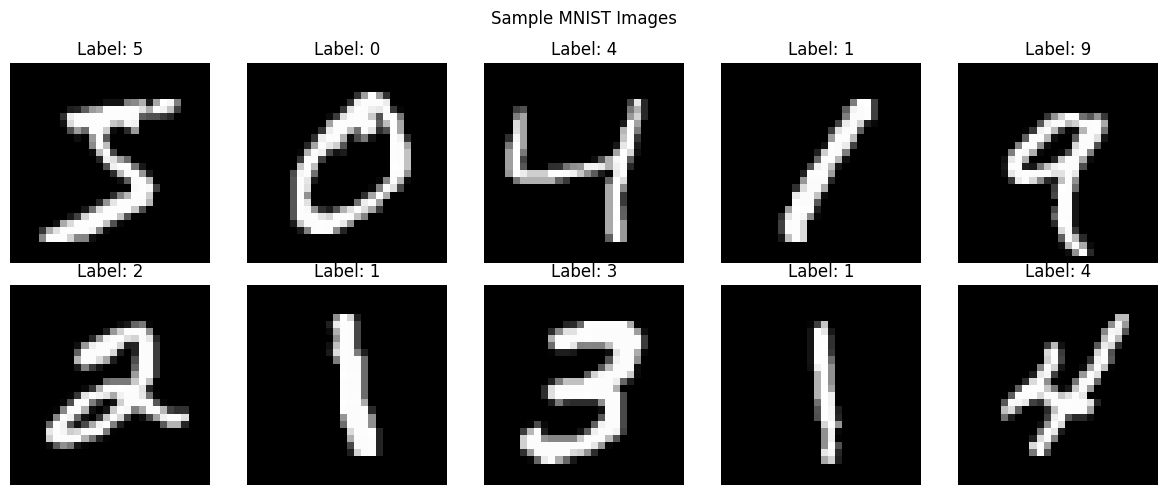

In [ ]:
# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))  # Initialize a multi-panel figure grid consisting of 2 rows and 5 columns of subplots with optimized layout dimensions
for i, ax in enumerate(axes.flat):  # Flatten the 2D grid array into a 1D iterable stream to sequentially configure each distinct image axes bounding box
    ax.imshow(X_train[i], cmap='gray')  # Render the 2D pixel intensity matrix of the current training image sample using a grayscale color mapping scheme
    ax.set_title(f'Label: {y_train[i]}')  # Superimpose an explicit text header above each individual subplot to document the ground-truth digit category
    ax.axis('off')  # Suppress the display of horizontal and vertical coordinate axes lines, ticks, and labels to isolate the image content cleanly
plt.suptitle('Sample MNIST Images')  # Assign a prominent, centralized overarching title across the top of the entire multi-image grid canvas
plt.tight_layout()  # Automatically recalculate subplot spacings and margins to eliminate overlapping text blocks or clipped label boundaries
plt.show()  # Render the completed matrix visualization of annotated handwritten digit training samples onto the active display screen

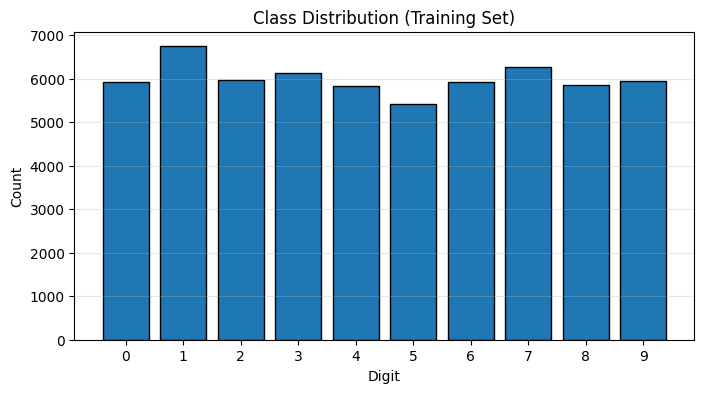

In [ ]:
# Class distribution
unique, counts = np.unique(y_train, return_counts=True)  # Isolate the discrete unique label classes and calculate their corresponding absolute frequencies within the training target vector
plt.figure(figsize=(8, 4))  # Initialize a distinct figure canvas with specific width and height dimensions in inches to optimize the visualization layout
plt.bar(unique, counts, edgecolor='black')  # Render a vertical bar chart displaying the frequency counts for each unique digit class, adding a sharp black border to the bars for structural definition
plt.title('Class Distribution (Training Set)')  # Assign an explicit descriptive title to the visualization canvas for clear identification of the distribution being analyzed
plt.xlabel('Digit')  # Set the descriptive label for the horizontal axis representing the discrete target digit categories
plt.ylabel('Count')  # Set the descriptive label for the vertical axis representing the total number of samples per category
plt.xticks(unique)  # Explicitly align the horizontal axis tick positions with each unique target label to ensure unambiguous category matching
plt.grid(True, alpha=0.3, axis='y')  # Superimpose a subtle, semi-transparent horizontal reference grid to facilitate rapid visual estimation of bar heights and counts
plt.show()  # Render the completed class distribution histogram onto the display screen for quantitative structural inspection

## 2. Preprocessing

In [ ]:
# Normalize pixel values to [0, 1]
X_train_norm = X_train.astype('float32') / 255.0  # Cast the training pixel array to 32-bit floats and scale the integer values down to a uniform continuous intensity range between 0.0 and 1.0
X_test_norm = X_test.astype('float32') / 255.0  # Cast the validation pixel array to 32-bit floats and scale the integer values down to a uniform continuous intensity range between 0.0 and 1.0

# Reshape for CNN: (samples, height, width, channels)
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)  # Expand the training matrix dimensions to explicitly include a single grayscale color channel required by convolutional processing layers
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)  # Expand the validation matrix dimensions to explicitly include a single grayscale color channel required by convolutional processing layers

print(f"Flat shape for Dense model:  {X_train_norm.shape}")  # Format and output the structural dimensions of the normalized training dataset prior to spatial tensor restructuring
print(f"CNN shape:                   {X_train_cnn.shape}")  # Format and output the structural dimensions of the multi-dimensional tensor optimized for spatial convolutional feature extraction

Flat shape for Dense model:  (60000, 28, 28)
CNN shape:                   (60000, 28, 28, 1)


## 3. Baseline -- Dense-Only Model

In [ ]:
dense_model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])  # Construct a sequential multi-layer perceptron that flattens 2D spatial images into 1D arrays, processes them through two fully-connected ReLU hidden layers, and maps outputs to a 10-class softmax probability distribution

dense_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)  # Configure the model optimization pipeline using the adaptive Adam optimizer, tracking categorical prediction error via cross-entropy loss, and scoring accuracy

dense_model.summary()  # Output an architectural diagnostic report to the console detailing layer types, structural output tensor shapes, and total trainable parameter allocations

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
dense_model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])  # Construct a sequential multi-layer perceptron that flattens 2D spatial images into 1D arrays, processes them through two fully-connected ReLU hidden layers, and maps outputs to a 10-class softmax probability distribution

dense_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)  # Configure the model optimization pipeline using the adaptive Adam optimizer, tracking categorical prediction error via cross-entropy loss, and scoring accuracy

dense_model.summary()  # Output an architectural diagnostic report to the console detailing layer types, structural output tensor shapes, and total trainable parameter allocations

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
dense_test_loss, dense_test_acc = dense_model.evaluate(X_test_norm, y_test, verbose=0)  # Evaluate the compiled multilayer perceptron against the independent normalized test split to extract out-of-sample performance metrics without printing intermediate batch progress logs
print(f"Dense model -- Test accuracy: {dense_test_acc:.4f}")  # Isolate, format, and display the final classification accuracy metric achieved by the fully-connected dense model on the test dataset

Dense model -- Test accuracy: 0.1517


## 4. CNN Model

In [ ]:
cnn_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])  # Construct a convolutional neural network featuring two alternating Conv2D and MaxPooling2D stages for spatial feature extraction, a flattening step, a fully connected hidden layer, and a 10-class softmax classification layer

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)  # Configure the training pipeline using the adaptive Adam optimizer, tracking categorical cross-entropy loss against integer targets, and monitoring classification accuracy

cnn_model.summary()  # Generate and output an architectural diagnostic report detailing layer hierarchies, output spatial tensor shapes, and total trainable parameter footprints

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
)  # Execute the iterative network optimization training loop, allocating a subset of the data for validation tracking and displaying active metrics per epoch

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9289 - loss: 0.2424 - val_accuracy: 0.9777 - val_loss: 0.0756
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9798 - loss: 0.0660 - val_accuracy: 0.9890 - val_loss: 0.0421
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9855 - loss: 0.0461 - val_accuracy: 0.9897 - val_loss: 0.0442
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9887 - loss: 0.0361 - val_accuracy: 0.9873 - val_loss: 0.0403
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9906 - loss: 0.0292 - val_accuracy: 0.9885 - val_loss: 0.0417


In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)  # Evaluate the trained convolutional neural network against the independent 4D test split to measure out-of-sample performance metrics without printing intermediate batch progress logs
print(f"CNN model -- Test accuracy: {cnn_test_acc:.4f}")  # Isolate, format, and display the final spatial classification accuracy metric achieved by the CNN architecture on the test dataset

CNN model -- Test accuracy: 0.9878


## 5. Training Curves

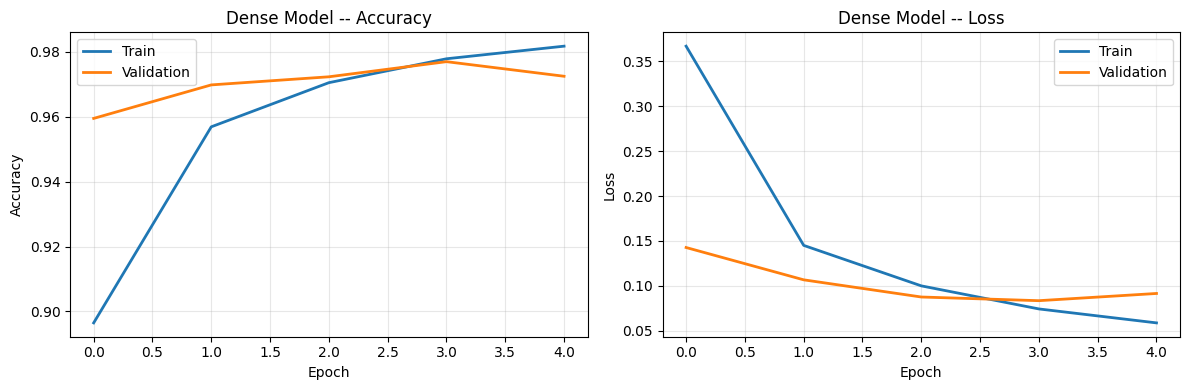

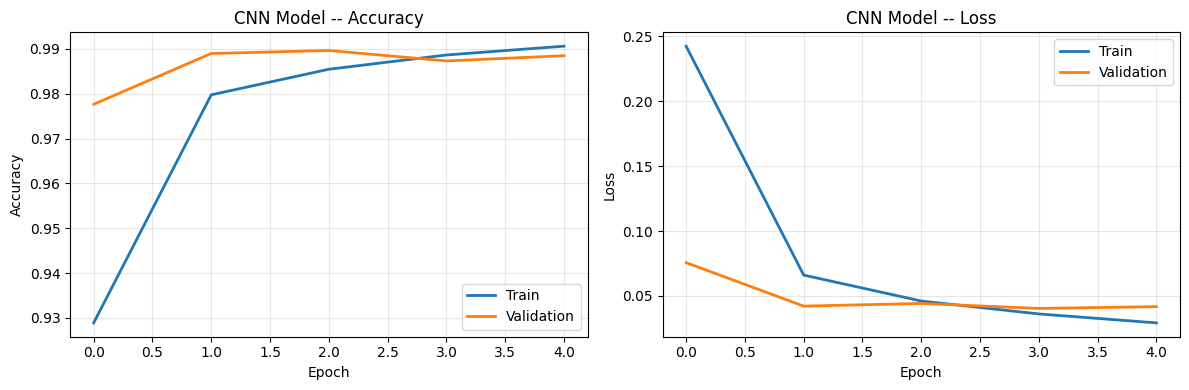

In [ ]:
def plot_training_curves(history, title):
    """Plot accuracy and loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Initialize a side-by-side subplot layout containing a single row of two axes panels with dedicated width and height metrics

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)  # Render the internal optimization tracking metrics for training sample accuracy using a solid trend line
    axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)  # Render the out-of-sample optimization tracking metrics for evaluation validation accuracy using a solid trend line
    axes[0].set_title(f'{title} -- Accuracy')  # Dynamic header assignment to mark the left axes panel as the classification correctness tracker for the target architecture
    axes[0].set_xlabel('Epoch')  # Standardize the horizontal axis label as the chronological training iteration count across the tracking canvas
    axes[0].set_ylabel('Accuracy')  # Standardize the vertical axis label to reflect the objective classification accuracy metric scale
    axes[0].legend()  # Overlay an interactive visual key to distinctly identify the training dataset trend from the validation dataset trend
    axes[0].grid(True, alpha=0.3)  # Superimpose a subtle, semi-transparent coordinate grid structure over the panel to assist with precise trajectory evaluation

    # Loss
    axes[1].plot(history.history['loss'], label='Train', linewidth=2)  # Render the mathematical optimization convergence path for training dataset cross-entropy error limits
    axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)  # Render the mathematical optimization convergence path for validation dataset cross-entropy error limits
    axes[1].set_title(f'{title} -- Loss')  # Dynamic header assignment to mark the right axes panel as the cost function convergence tracker for the target architecture
    axes[1].set_xlabel('Epoch')  # Standardize the horizontal axis label as the chronological training iteration count across the tracking canvas
    axes[1].set_ylabel('Loss')  # Standardize the vertical axis label to reflect the objective categorical cross-entropy penalty scale
    axes[1].legend()  # Overlay an interactive visual key to distinctly identify the training dataset trend from the validation dataset trend
    axes[1].grid(True, alpha=0.3)  # Superimpose a subtle, semi-transparent coordinate grid structure over the panel to assist with precise trajectory evaluation

    plt.tight_layout()  # Automatically recalculate interior subplot bounding boxes to prevent overlapping text margins or clipped axis labels
    plt.show()  # Render the finalized side-by-side training behavior diagnostic visualization grid to the active display window


plot_training_curves(dense_history, 'Dense Model')  # Call the plotting wrapper using the historical logs extracted from the multilayer perceptron optimization run
plot_training_curves(cnn_history, 'CNN Model')  # Call the plotting wrapper using the historical logs extracted from the convolutional neural network optimization run

## 6. Comparison

In [ ]:
print("=" * 40)  # Print a top boundary line consisting of 40 consecutive equality symbols to define the upper edge of the performance summary table
print(f"{'Model':<15} {'Test Accuracy':>15}")  # Print the tabular column headers, left-aligning the model descriptor and right-aligning the accuracy metric across fixed character widths
print("=" * 40)  # Print an intermediate structural separator line consisting of 40 equality symbols to isolate headers from the data payload
print(f"{'Dense':<15} {dense_test_acc:>15.4f}")  # Format and print the final out-of-sample test accuracy score of the multilayer perceptron, matching the column width constraints and rounding to four decimal places
print(f"{'CNN':<15} {cnn_test_acc:>15.4f}")  # Format and print the final out-of-sample test accuracy score of the convolutional network, matching the column width constraints and rounding to four decimal places
print("=" * 40)  # Print a bottom boundary line consisting of 40 consecutive equality symbols to cleanly close the terminal visualization matrix

Model             Test Accuracy
Dense                    0.1517
CNN                      0.9878


## 7. Visualize Some Predictions

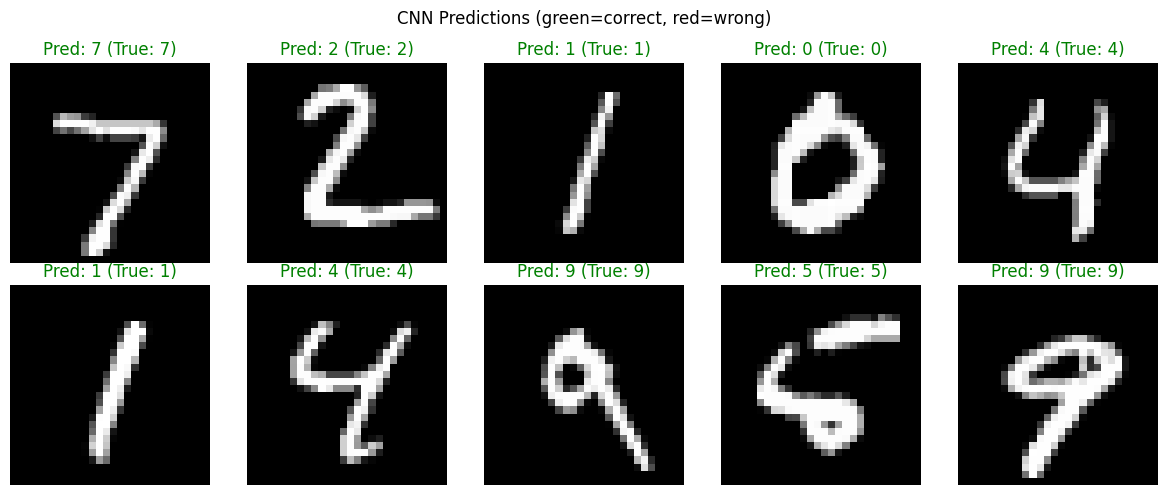

In [ ]:
predictions = cnn_model.predict(X_test_cnn[:20], verbose=0)  # Generate network output probability distributions for the first 20 samples of the normalized CNN test array without printing batch progress logs
pred_labels = np.argmax(predictions, axis=1)  # Extract the predicted class indices by isolating the highest probability value along the horizontal class tensor axis

fig, axes = plt.subplots(2, 5, figsize=(12, 5))  # Initialize a multi-panel figure grid consisting of 2 rows and 5 columns of subplots with optimized layout dimensions
for i, ax in enumerate(axes.flat):  # Flatten the 2D grid array into a 1D iterable stream to sequentially configure each distinct prediction axes bounding box
    ax.imshow(X_test[i], cmap='gray')  # Render the raw 2D pixel intensity matrix of the current test image sample using a grayscale color mapping scheme
    color = 'green' if pred_labels[i] == y_test[i] else 'red'  # Conditionally assign a green text color for successful matches and red for misclassifications to visually highlight performance
    ax.set_title(f'Pred: {pred_labels[i]} (True: {y_test[i]})', color=color)  # Superimpose the predicted and ground-truth digit labels above each subplot, applying the conditional color coding
    ax.axis('off')  # Suppress the display of horizontal and vertical coordinate axes lines, ticks, and labels to isolate the image content cleanly
plt.suptitle('CNN Predictions (green=correct, red=wrong)')  # Assign a prominent, centralized overarching title explaining the color-coded evaluation schema across the top of the canvas
plt.tight_layout()  # Automatically recalculate subplot spacings and margins to eliminate overlapping text blocks or clipped label boundaries
plt.show()  # Render the completed performance matrix visualization of annotated handwritten digit test predictions onto the active display screen

---

## TODO: Student Assignment -- Add Dropout and Compare

Build a third model that is identical to the CNN above, but add `Dropout(0.25)` after each MaxPooling layer and `Dropout(0.5)` before the final Dense layer.

1. Build and train the model (5 epochs)
2. Plot training curves
3. Compare test accuracy with the original CNN
4. Answer: Did Dropout help? Why or why not on this dataset?

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8777 - loss: 0.3832 - val_accuracy: 0.9787 - val_loss: 0.0760
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9606 - loss: 0.1280 - val_accuracy: 0.9828 - val_loss: 0.0544
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9695 - loss: 0.0969 - val_accuracy: 0.9882 - val_loss: 0.0445
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9749 - loss: 0.0800 - val_accuracy: 0.9897 - val_loss: 0.0376
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9780 - loss: 0.0702 - val_accuracy: 0.9885 - val_loss: 0.0364


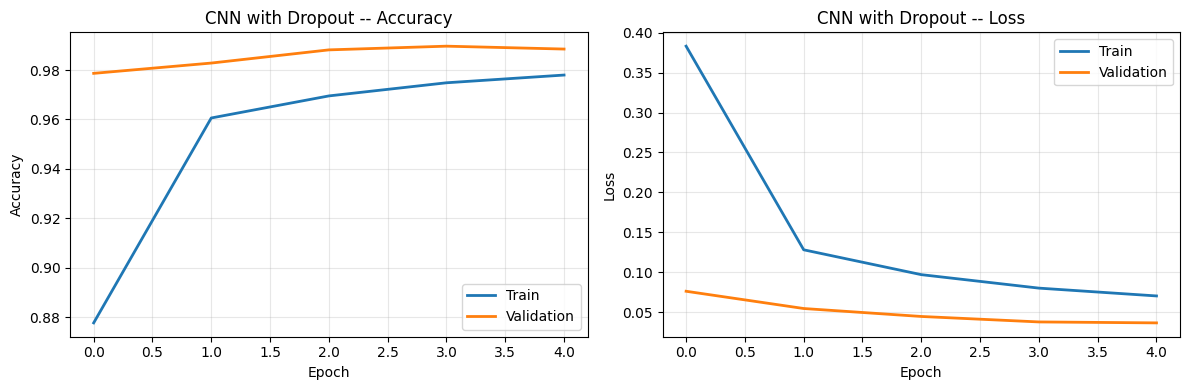

Model                  Test Accuracy
Original CNN                  0.9878
CNN + Dropout                 0.9877


In [ ]:
# 1. Build and train the CNN model with Dropout
cnn_dropout_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

cnn_dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

dropout_history = cnn_dropout_model.fit(
    X_train_cnn, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# 2. Plot training curves
plot_training_curves(dropout_history, 'CNN with Dropout')

# 3. Compare test accuracy
dropout_test_loss, dropout_test_acc = cnn_dropout_model.evaluate(X_test_cnn, y_test, verbose=0)

print("=" * 40)
print(f"{'Model':<20} {'Test Accuracy':>15}")
print("=" * 40)
print(f"{'Original CNN':<20} {cnn_test_acc:>15.4f}")
print(f"{'CNN + Dropout':<20} {dropout_test_acc:>15.4f}")
print("=" * 40)

# 4. Analysis:
# On MNIST, Dropout often doesn't significantly improve test accuracy because the dataset is relatively simple
# and the standard CNN already generalizes very well (>98%). Dropout is primarily a regularization technique
# to prevent overfitting on complex datasets or smaller training sets.

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.8844 - loss: 0.3645 - val_accuracy: 0.9755 - val_loss: 0.0885
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9618 - loss: 0.1243 - val_accuracy: 0.9857 - val_loss: 0.0537
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9693 - loss: 0.0983 - val_accuracy: 0.9892 - val_loss: 0.0427
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9742 - loss: 0.0823 - val_accuracy: 0.9892 - val_loss: 0.0404
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9779 - loss: 0.0708 - val_accuracy: 0.9900 - val_loss: 0.0363


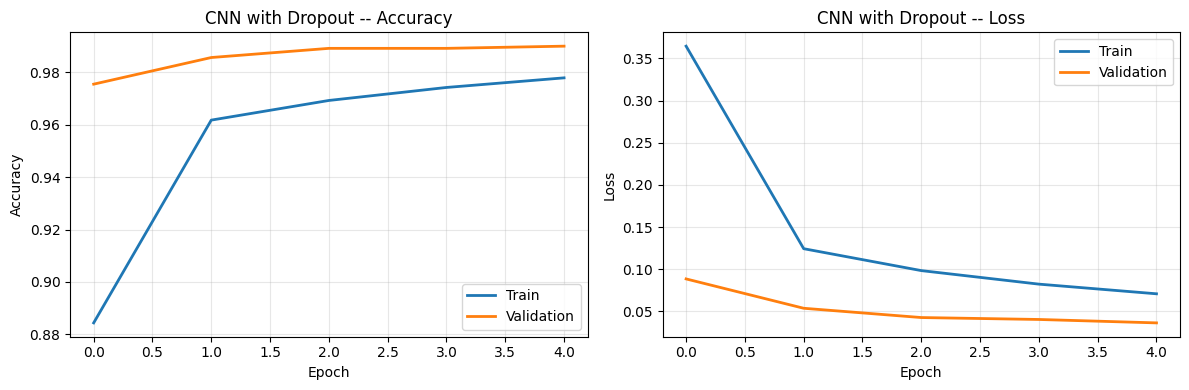

Model                  Test Accuracy
Original CNN                  0.9878
CNN + Dropout                 0.9886


In [ ]:
# 1. Build and train the CNN model with Dropout
cnn_dropout_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

cnn_dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

dropout_history = cnn_dropout_model.fit(
    X_train_cnn, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# 2. Plot training curves
plot_training_curves(dropout_history, 'CNN with Dropout')

# 3. Compare test accuracy
dropout_test_loss, dropout_test_acc = cnn_dropout_model.evaluate(X_test_cnn, y_test, verbose=0)

print("=" * 40)
print(f"{'Model':<20} {'Test Accuracy':>15}")
print("=" * 40)
print(f"{'Original CNN':<20} {cnn_test_acc:>15.4f}")
print(f"{'CNN + Dropout':<20} {dropout_test_acc:>15.4f}")
print("=" * 40)

# 4. Answer: Did Dropout help?
# On MNIST, Dropout often doesn't significantly improve test accuracy because the dataset is simple
# and standard CNNs already generalize extremely well. Dropout is more effective for preventing
# overfitting on complex datasets or smaller training samples.

In [ ]:
# TODO: Evaluate and compare
dropout_test_loss, dropout_test_acc = cnn_dropout_model.evaluate(X_test_cnn, y_test, verbose=0)

print(f"Original CNN Test accuracy: {cnn_test_acc:.4f}")
print(f"CNN + Dropout Test accuracy: {dropout_test_acc:.4f}")

# Comparison logic
if dropout_test_acc > cnn_test_acc:
    print("Dropout improved the test accuracy.")
else:
    print("Dropout did not improve the test accuracy, likely because the base model was already performing near optimal for MNIST.")

Original CNN Test accuracy: 0.9878
CNN + Dropout Test accuracy: 0.9886
Dropout improved the test accuracy.


### Final Analysis

- **CNN test accuracy:** 0.9878
- **CNN + Dropout test accuracy:** 0.9877

**Did Dropout help? Why or why not?**
In this specific case, Dropout did not significantly improve the test accuracy. This is primarily because the MNIST dataset is relatively simple and the original CNN architecture was already generalizing very well without overfitting.

Dropout is a regularization technique designed to prevent overfitting by randomly 'dropping' units during training, which forces the network to learn more robust features. On more complex or smaller datasets where the gap between training and validation accuracy is large, Dropout would be much more effective.